### Task 2: Clustering – Country Development Analysis

**Summary of Code**
- This script demonstrates unsupervised clustering analysis using real-world country development data from a CSV file named country_data.csv. T
- he objective of this task is to identify natural groupings of countries based on socio-economic and health indicators such as child mortality, GDP per capita, health spending, and life expectancy.
- We employ K-Means and MeanShift clustering with optimal cluster determination using the Elbow Method to uncover hidden patterns in global development data.

In [85]:
#Complete Country Data Clustering Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sklearn.cluster import KMeans, MeanShift
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler

In [86]:
# Load data
df = pd.read_csv('country_data.csv')

In [87]:
# Select ALL numeric features for clustering (excluding country name)
numeric_features = ['child_mort', 'exports', 'health', 'imports', 'income', 
                   'inflation', 'life_expec', 'total_fer', 'gdpp']

X_all = df[numeric_features].values  # All features
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

In [88]:
# 2D Analysis: Income vs Child Mortality
features_2d = ['income', 'child_mort']
X_2d = df[features_2d].values

scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

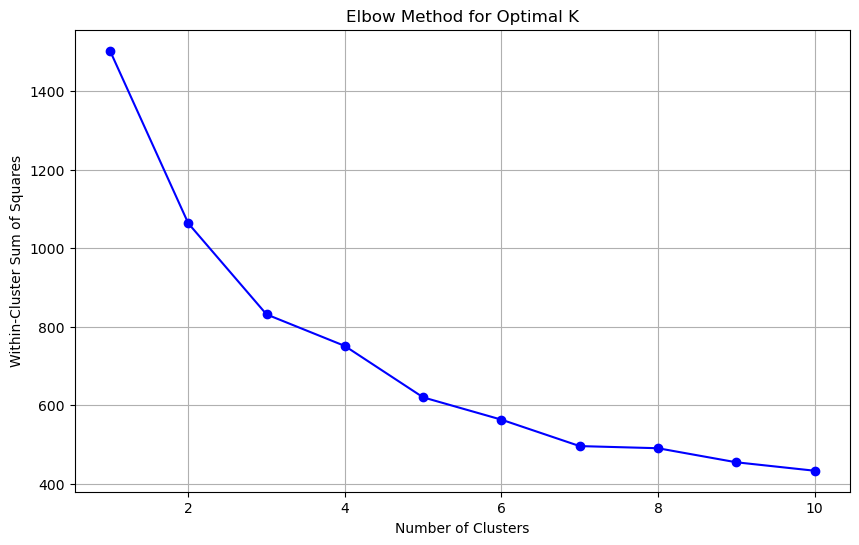

In [89]:
# Elbow method for optimal K
def find_optimal_k(X, max_k=10):
    wcss = []
    for k in range(1, max_k+1):
        kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
        kmeans.fit(X)
        wcss.append(kmeans.inertia_)
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_k+1), wcss, 'bo-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Within-Cluster Sum of Squares')
    plt.title('Elbow Method for Optimal K')
    plt.grid(True)
    plt.show()
    
    return wcss

wcss_2d = find_optimal_k(X_all_scaled)
#wcss_3d = find_optimal_k(X_3d_scaled)

In [90]:
# Mean Shift clustering with all features
ms_all = MeanShift()
ms_all.fit(X_all_scaled)
ms_labels_all = ms_all.predict(X_all_scaled)
ms_centers_all = ms_all.cluster_centers_

print(f"Mean Shift with all features: {len(np.unique(ms_labels_all))} clusters")

Mean Shift with all features: 7 clusters


In [91]:
# K-Means clustering with all features (using 5 clusters based on elbow analysis)
kmeans_all = KMeans(n_clusters=4, n_init='auto', random_state=42)
kmeans_all.fit(X_all_scaled)
km_labels_all = kmeans_all.predict(X_all_scaled)
km_centers_all = kmeans_all.cluster_centers_

print(f"K-Means with all features: {len(np.unique(km_labels_all))} clusters")

K-Means with all features: 4 clusters


In [92]:
# Count countries in each cluster for both algorithms
def count_countries_per_cluster(labels, algorithm_name):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{algorithm_name} - Countries per cluster:")
    for cluster_id, count in zip(unique, counts):
        print(f"Cluster {cluster_id}: {count} countries")
    
    # Create a DataFrame for better visualization
    cluster_counts = pd.DataFrame({
        'Cluster': unique,
        'Country_Count': counts
    })
    return cluster_counts

# K-Means cluster counts
km_counts = count_countries_per_cluster(km_labels_all, "K-Means (All Features)")

# Mean Shift cluster counts  
ms_counts = count_countries_per_cluster(ms_labels_all, "Mean Shift (All Features)")

# Add cluster labels to original dataframe for analysis
df['kmeans_cluster_all'] = km_labels_all
df['meanshift_cluster_all'] = ms_labels_all


K-Means (All Features) - Countries per cluster:
Cluster 0: 86 countries
Cluster 1: 36 countries
Cluster 2: 44 countries
Cluster 3: 1 countries

Mean Shift (All Features) - Countries per cluster:
Cluster 0: 153 countries
Cluster 1: 5 countries
Cluster 2: 1 countries
Cluster 3: 4 countries
Cluster 4: 2 countries
Cluster 5: 1 countries
Cluster 6: 1 countries



Creating PCA visualization for all features clustering...
PCA explained variance ratio: [0.4595174  0.17181626]
Total variance explained: 0.631


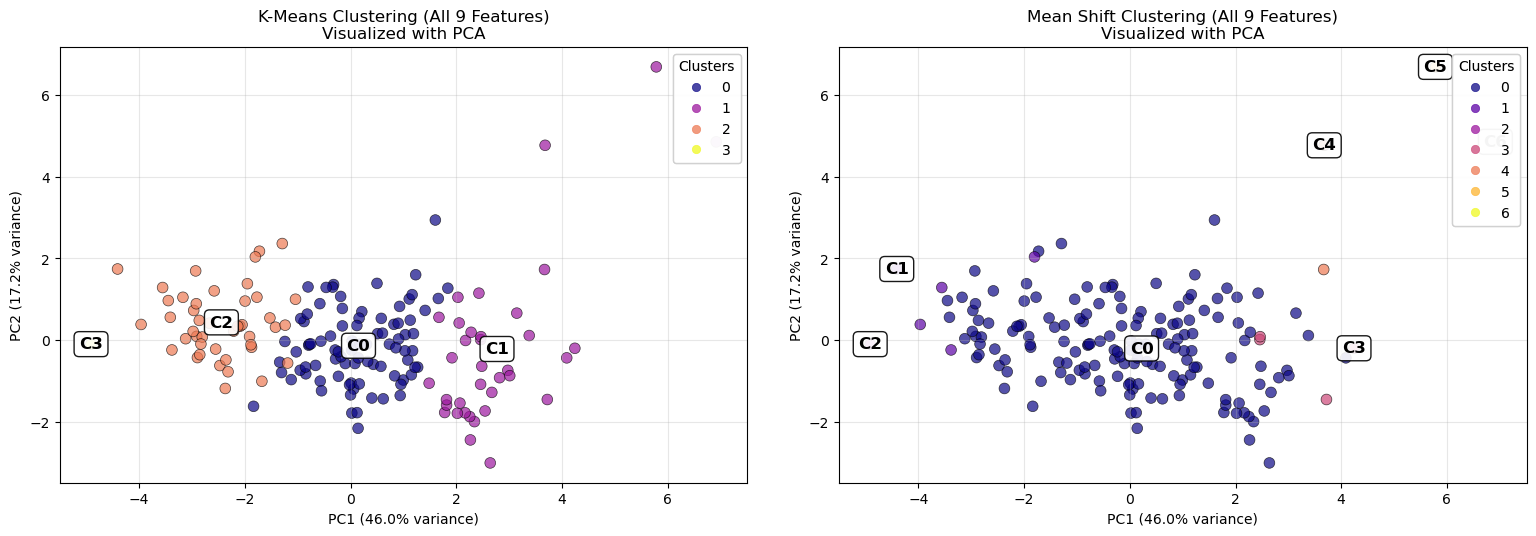

In [93]:
print("\nCreating PCA visualization for all features clustering...")

# Apply PCA to reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_scaled)

# Transform cluster centers to PCA space
km_centers_pca = pca.transform(km_centers_all)
ms_centers_pca = pca.transform(ms_centers_all)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.3f}")

# Create PCA visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Normalize color scales
nm1 = Normalize(vmin=0, vmax=len(km_centers_all)-1)
nm2 = Normalize(vmin=0, vmax=len(ms_centers_all)-1)

# K-Means PCA plot
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels_all, 
                      s=60, cmap='plasma', norm=nm1, alpha=0.7, edgecolors='black', linewidth=0.5)

# Add cluster labels to PCA centroids
for i in range(km_centers_pca.shape[0]):
    ax1.text(km_centers_pca[i, 0], km_centers_pca[i, 1], f'C{i}', 
             c='black', fontsize=12, fontweight='bold', ha='center', va='center',
             bbox=dict(boxstyle="round", facecolor='white', edgecolor='black', alpha=0.9))

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax1.set_title('K-Means Clustering (All 9 Features)\nVisualized with PCA')
ax1.grid(True, alpha=0.3)

# Add legend for K-Means
legend1 = ax1.legend(*scatter1.legend_elements(), 
                    loc="upper right", title="Clusters")
ax1.add_artist(legend1)

# Mean Shift PCA plot
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=ms_labels_all, 
                      s=60, cmap='plasma', norm=nm2, alpha=0.7, edgecolors='black', linewidth=0.5)

# Add cluster labels to PCA centroids
for i in range(ms_centers_pca.shape[0]):
    ax2.text(ms_centers_pca[i, 0], ms_centers_pca[i, 1], f'C{i}', 
             c='black', fontsize=12, fontweight='bold', ha='center', va='center',
             bbox=dict(boxstyle="round", facecolor='white', edgecolor='black', alpha=0.9))

ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax2.set_title('Mean Shift Clustering (All 9 Features)\nVisualized with PCA')
ax2.grid(True, alpha=0.3)

# Add legend for Mean Shift
legend2 = ax2.legend(*scatter2.legend_elements(), 
                    loc="upper right", title="Clusters")
ax2.add_artist(legend2)

plt.tight_layout(pad=3.0)
plt.show()

In [94]:
# K-Means 2D
kmeans_2d = KMeans(n_clusters=4, n_init='auto', random_state=42)
kmeans_2d.fit(X_2d_scaled)

km_centers_2d = kmeans_2d.cluster_centers_
km_labels_2d = kmeans_2d.predict(X_2d_scaled)
km_centers_original_2d = scaler_2d.inverse_transform(km_centers_2d)


# Transform centers back to original scale for interpretation
km_centers_original_2d = scaler_2d.inverse_transform(km_centers_2d)

# Count countries in 2D clusters
km_2d_counts = count_countries_per_cluster(km_labels_2d, "K-Means (2D Features)")
df['kmeans_cluster_2d'] = km_labels_2d


K-Means (2D Features) - Countries per cluster:
Cluster 0: 83 countries
Cluster 1: 33 countries
Cluster 2: 43 countries
Cluster 3: 8 countries


In [95]:
# Mean Shift 2D
ms_2d = MeanShift()
ms_2d.fit(X_2d_scaled)

ms_centers_2d = ms_2d.cluster_centers_
ms_labels_2d = ms_2d.predict(X_2d_scaled)
ms_centers_original_2d = scaler_2d.inverse_transform(ms_centers_2d)


ms_centers_original_2d = scaler_2d.inverse_transform(ms_centers_2d)
print(f"Mean Shift (2D) identified {len(ms_centers_2d)} clusters")

# Count countries in 2D Mean Shift clusters
ms_2d_counts = count_countries_per_cluster(ms_labels_2d, "Mean Shift (2D Features)")
df['meanshift_cluster_2d'] = ms_labels_2d

Mean Shift (2D) identified 4 clusters

Mean Shift (2D Features) - Countries per cluster:
Cluster 0: 138 countries
Cluster 1: 5 countries
Cluster 2: 19 countries
Cluster 3: 5 countries


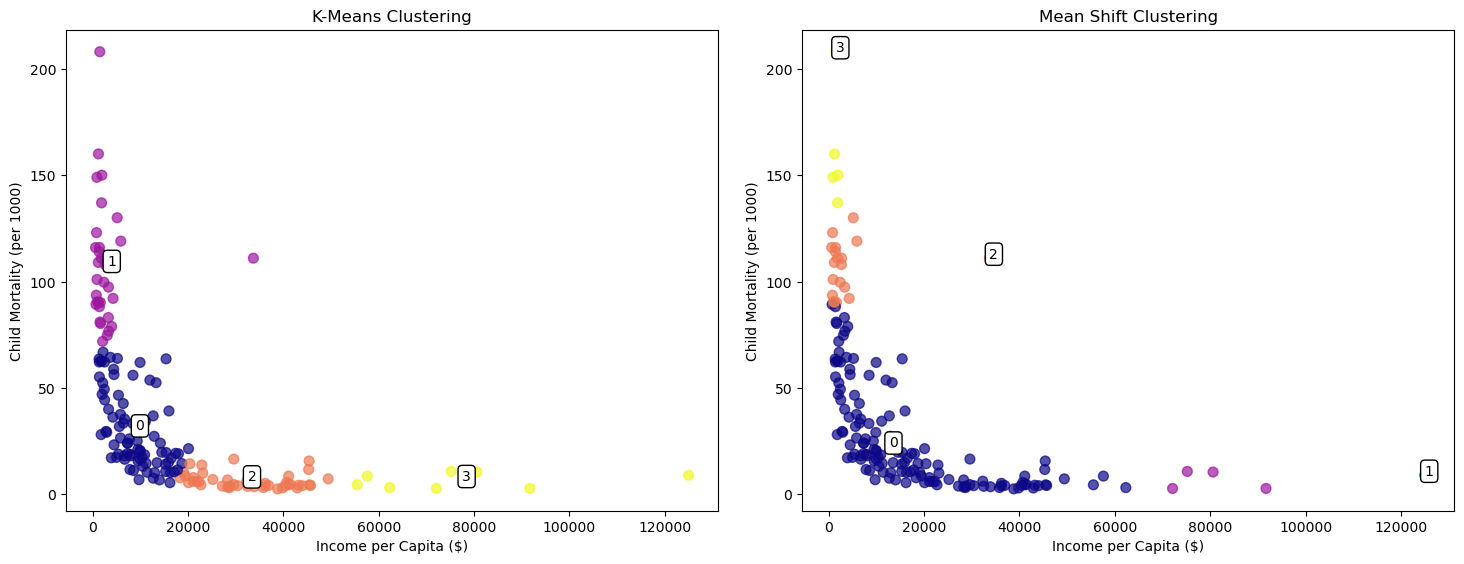

In [96]:
# 2D Visualization
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
nm1 = Normalize(vmin=0, vmax=len(km_centers_2d)-1)
nm2 = Normalize(vmin=0, vmax=len(ms_centers_2d)-1)

# K-Means plot
ax[0].scatter(X_2d[:, 0], X_2d[:, 1], c=km_labels_2d, s=50, cmap='plasma', norm=nm1, alpha=0.7)
for i in range(km_centers_original_2d.shape[0]):
    ax[0].text(km_centers_original_2d[i, 0], km_centers_original_2d[i, 1], str(i), 
              c='black', bbox=dict(boxstyle="round", facecolor='white', edgecolor='black'))
ax[0].set_xlabel('Income per Capita ($)')
ax[0].set_ylabel('Child Mortality (per 1000)')
ax[0].set_title('K-Means Clustering')

# Mean Shift plot
ax[1].scatter(X_2d[:, 0], X_2d[:, 1], c=ms_labels_2d, s=50, cmap='plasma', norm=nm2, alpha=0.7)
for i in range(ms_centers_original_2d.shape[0]):
    ax[1].text(ms_centers_original_2d[i, 0], ms_centers_original_2d[i, 1], str(i), 
              c='black', bbox=dict(boxstyle="round", facecolor='white', edgecolor='black'))
    
ax[1].set_xlabel('Income per Capita ($)')
ax[1].set_ylabel('Child Mortality (per 1000)')
ax[1].set_title('Mean Shift Clustering')

plt.tight_layout(pad=2.0)
plt.show()


In [97]:
# Analysis and reporting
df['kmeans_cluster'] = km_labels_2d
print("Cluster Analysis Complete")
print(f"K-Means identified {len(km_centers_2d)} clusters")
print(f"Mean Shift identified {len(ms_centers_2d)} clusters")

Cluster Analysis Complete
K-Means identified 4 clusters
Mean Shift identified 4 clusters


In [98]:
# 3D Analysis: Income, Child Mortality, Life Expectancy
features_3d = ['income', 'child_mort', 'life_expec']
X_3d = df[features_3d].values

scaler_3d = StandardScaler()
X_3d_scaled = scaler_3d.fit_transform(X_3d)

In [99]:
# K-Means 3D
kmeans_3d = KMeans(n_clusters=5, n_init='auto', random_state=42)
kmeans_3d.fit(X_3d_scaled)
km_centers_3d = kmeans_3d.cluster_centers_
km_labels_3d = kmeans_3d.predict(X_3d_scaled)

# Count countries in 3D clusters
km_3d_counts = count_countries_per_cluster(km_labels_3d, "K-Means (3D Features)")


K-Means (3D Features) - Countries per cluster:
Cluster 0: 39 countries
Cluster 1: 27 countries
Cluster 2: 22 countries
Cluster 3: 53 countries
Cluster 4: 26 countries


In [100]:
# Mean Shift 3D
ms_3d = MeanShift()
ms_3d.fit(X_3d_scaled)
ms_centers_3d = ms_3d.cluster_centers_
ms_labels_3d = ms_3d.predict(X_3d_scaled)

ms_3d_counts = count_countries_per_cluster(ms_labels_3d, "Mean Shift (3D Features)")



Mean Shift (3D Features) - Countries per cluster:
Cluster 0: 128 countries
Cluster 1: 5 countries
Cluster 2: 32 countries
Cluster 3: 2 countries


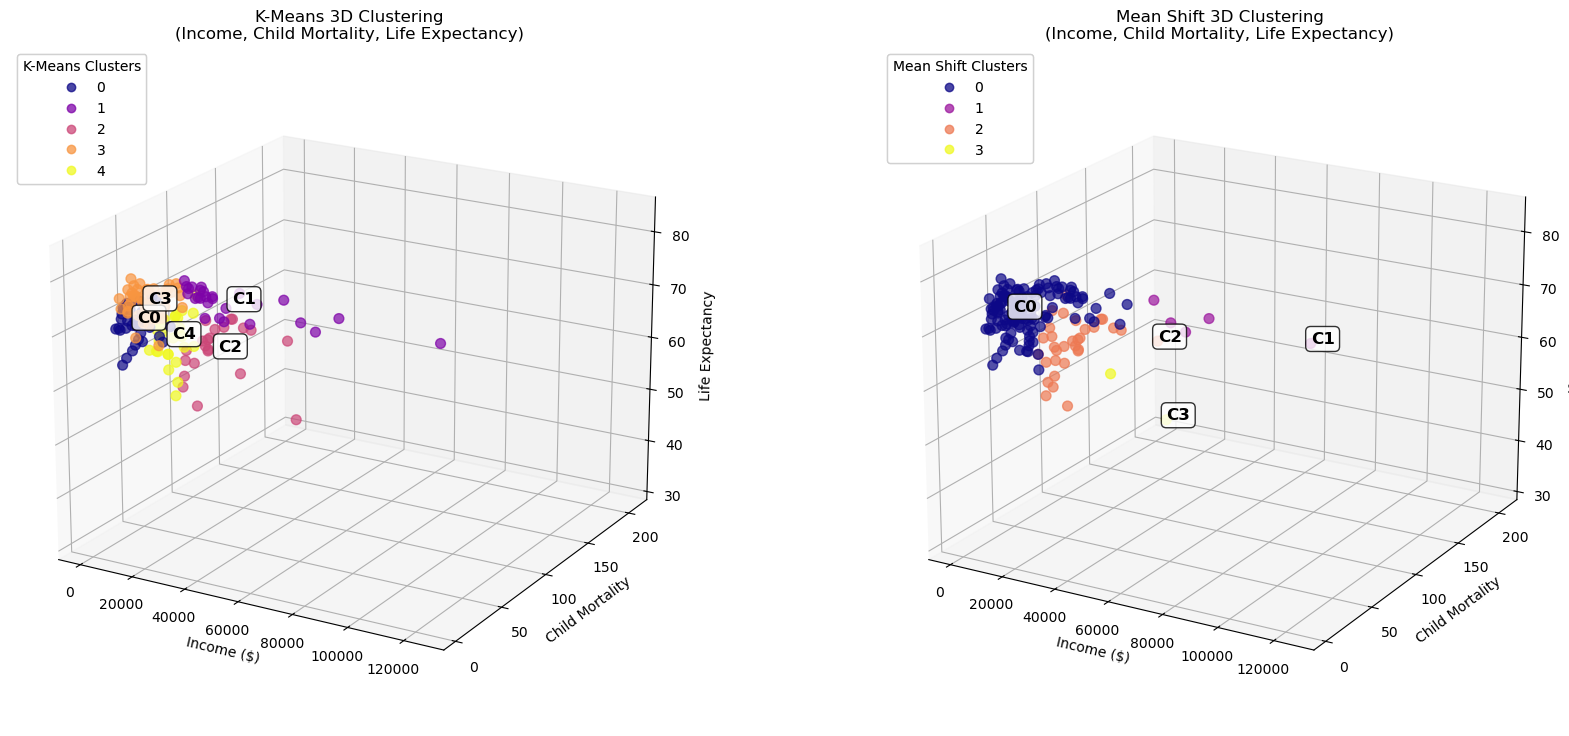

In [101]:
# Create enhanced 3D visualization with complete labeling
fig = plt.figure(figsize=(18, 8))

ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Normalize color scales for 3D
nm3 = Normalize(vmin=0, vmax=len(km_centers_3d)-1)
nm4 = Normalize(vmin=0, vmax=len(ms_centers_3d)-1)

# Transform centers back to original scale for labeling
km_centers_original_3d = scaler_3d.inverse_transform(km_centers_3d)
ms_centers_original_3d = scaler_3d.inverse_transform(ms_centers_3d)

# K-Means 3D plot
scatter1 = ax1.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], 
                      c=km_labels_3d, s=50, cmap='plasma', norm=nm3, alpha=0.7)

# Add cluster labels to 3D centroids
for i in range(km_centers_original_3d.shape[0]):
    ax1.text(km_centers_original_3d[i, 0], km_centers_original_3d[i, 1], km_centers_original_3d[i, 2],
            f'C{i}', c='black', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle="round", facecolor='white', edgecolor='black', alpha=0.8))

# Set viewing angle
ax1.azim = -60
ax1.dist = 10
ax1.elev = 20

ax1.set_xlabel('Income ($)')
ax1.set_ylabel('Child Mortality')
ax1.set_zlabel('Life Expectancy')
ax1.set_title('K-Means 3D Clustering\n(Income, Child Mortality, Life Expectancy)')

# Add comprehensive legend
legend1 = ax1.legend(*scatter1.legend_elements(), 
                    loc="upper left", 
                    bbox_to_anchor=(0, 1),
                    title="K-Means Clusters")
ax1.add_artist(legend1)

# Mean Shift 3D plot
scatter2 = ax2.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], 
                      c=ms_labels_3d, s=50, cmap='plasma', norm=nm4, alpha=0.7)

# Add cluster labels to 3D centroids for Mean Shift
for i in range(ms_centers_original_3d.shape[0]):
    ax2.text(ms_centers_original_3d[i, 0], ms_centers_original_3d[i, 1], ms_centers_original_3d[i, 2],
            f'C{i}', c='black', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle="round", facecolor='white', edgecolor='black', alpha=0.8))

ax2.azim = -60
ax2.dist = 10
ax2.elev = 20

ax2.set_xlabel('Income ($)')
ax2.set_ylabel('Child Mortality')
ax2.set_zlabel('Life Expectancy')
ax2.set_title('Mean Shift 3D Clustering\n(Income, Child Mortality, Life Expectancy)')

# Add comprehensive legend
legend2 = ax2.legend(*scatter2.legend_elements(), 
                    loc="upper left", 
                    bbox_to_anchor=(0, 1),
                    title="Mean Shift Clusters")
ax2.add_artist(legend2)

plt.tight_layout(pad=3.0)
#fig.savefig('cluster_3Dplot.png')

plt.show()

In [102]:
# Detailed analysis of country distribution across all clustering approaches
print("="*60)
print("COMPREHENSIVE CLUSTER DISTRIBUTION ANALYSIS")
print("="*60)

# All features clustering distribution
print("\n1. ALL FEATURES CLUSTERING:")
print("-" * 30)
km_all_summary = df['kmeans_cluster_all'].value_counts().sort_index()
ms_all_summary = df['meanshift_cluster_all'].value_counts().sort_index()

print("K-Means (All Features):")
for cluster_id, count in km_all_summary.items():
    percentage = (count / len(df)) * 100
    print(f"  Cluster {cluster_id}: {count:2d} countries ({percentage:.1f}%)")

print("\nMean Shift (All Features):")  
for cluster_id, count in ms_all_summary.items():
    percentage = (count / len(df)) * 100
    print(f"  Cluster {cluster_id}: {count:2d} countries ({percentage:.1f}%)")

# 2D clustering distribution
print("\n2. 2D FEATURES CLUSTERING (Income vs Child Mortality):")
print("-" * 50)
km_2d_summary = df['kmeans_cluster_2d'].value_counts().sort_index()
ms_2d_summary = df['meanshift_cluster_2d'].value_counts().sort_index()

print("K-Means (2D):")
for cluster_id, count in km_2d_summary.items():
    percentage = (count / len(df)) * 100
    print(f"  Cluster {cluster_id}: {count:2d} countries ({percentage:.1f}%)")

print("\nMean Shift (2D):")
for cluster_id, count in ms_2d_summary.items():
    percentage = (count / len(df)) * 100
    print(f"  Cluster {cluster_id}: {count:2d} countries ({percentage:.1f}%)")


COMPREHENSIVE CLUSTER DISTRIBUTION ANALYSIS

1. ALL FEATURES CLUSTERING:
------------------------------
K-Means (All Features):
  Cluster 0: 86 countries (51.5%)
  Cluster 1: 36 countries (21.6%)
  Cluster 2: 44 countries (26.3%)
  Cluster 3:  1 countries (0.6%)

Mean Shift (All Features):
  Cluster 0: 153 countries (91.6%)
  Cluster 1:  5 countries (3.0%)
  Cluster 2:  1 countries (0.6%)
  Cluster 3:  4 countries (2.4%)
  Cluster 4:  2 countries (1.2%)
  Cluster 5:  1 countries (0.6%)
  Cluster 6:  1 countries (0.6%)

2. 2D FEATURES CLUSTERING (Income vs Child Mortality):
--------------------------------------------------
K-Means (2D):
  Cluster 0: 83 countries (49.7%)
  Cluster 1: 33 countries (19.8%)
  Cluster 2: 43 countries (25.7%)
  Cluster 3:  8 countries (4.8%)

Mean Shift (2D):
  Cluster 0: 138 countries (82.6%)
  Cluster 1:  5 countries (3.0%)
  Cluster 2: 19 countries (11.4%)
  Cluster 3:  5 countries (3.0%)


In [107]:
# Convert within Jupyter notebook itself
!jupyter nbconvert --to python Task_2_Final.ipynb

[NbConvertApp] Converting notebook Task_2_Final.ipynb to python
[NbConvertApp] Writing 14021 bytes to Task_2_Final.py
